<a href="https://colab.research.google.com/github/phanhieu25/auto-mpg-analysis/blob/main/auto_mpg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<style>
  .container { width: 95% !important; }
  body { font-family: "Times New Roman", sans-serif !important; }
</style>





# **Project - Group 11**
## **National Economic University - BFT 65**
### Course: Introduction to R
### Instructor: Mr. Huan Vu
### Members:
- Phan Đức Hiếu
- Hứa Văn Phúc
- Trần Huyền Trang

--------------------------------------------------------------------------------

This project presents a comprehensive analysis of vehicle fuel efficiency using the Auto-MPG dataset (Quinlan, 1993). The dataset comprises technical specifications for 398 automobiles from the 1970s and early 1980s, encompassing distinct features such as **Vehicle Weight, Horsepower, Displacement, and Origin.** The primary objective is to construct a robust predictive model for the continuous target variable, **Miles Per Gallon (MPG)**, thereby identifying the critical engineering factors that drive fuel economy.

We begin by establishing a baseline using **Linear Regression (OLS)** to assess linear relationships and interpretability. However, anticipating the limitations of linear models in handling complex engineering data, we subsequently implement a **Generalized Additive Model (GAM)**. Our analysis focuses on applying statistical modeling to quantify the complex relationships between these engineering features, ensuring both high predictive accuracy and the interpretability required for strategic decision-making.

# **I. Data Introduction**

In [ ]:
#install necessary package
install.packages(c("tidyverse", "ggcorrplot","caret","car","lmtest","tseries"))
library(tidyverse)
library(ggcorrplot)
library(caret)
library(car)
library(lmtest)
library(tseries)

In [ ]:
# read the dataset
mpg <- read.csv("auto-mpg.csv", na.strings = "?")
head(mpg)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model.year,origin,car.name
,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<chr>
1,18,8,307,130,3504,12.0,70,1,chevrolet chevelle malibu
2,15,8,350,165,3693,11.5,70,1,buick skylark 320
3,18,8,318,150,3436,11.0,70,1,plymouth satellite
4,16,8,304,150,3433,12.0,70,1,amc rebel sst
5,17,8,302,140,3449,10.5,70,1,ford torino
6,15,8,429,198,4341,10.0,70,1,ford galaxie 500


In [ ]:
# check the dataset structure
str(mpg)

'data.frame':	398 obs. of  9 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : int  8 8 8 8 8 8 8 8 8 8 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : int  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acceleration: num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ model.year  : int  70 70 70 70 70 70 70 70 70 70 ...
 $ origin      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ car.name    : chr  "chevrolet chevelle malibu" "buick skylark 320" "plymouth satellite" "amc rebel sst" ...


In [ ]:
# summary the dataset
summary(mpg)

      mpg          cylinders      displacement     horsepower        weight    
 Min.   : 9.00   Min.   :3.000   Min.   : 68.0   Min.   : 46.0   Min.   :1613  
 1st Qu.:17.50   1st Qu.:4.000   1st Qu.:104.2   1st Qu.: 75.0   1st Qu.:2224  
 Median :23.00   Median :4.000   Median :148.5   Median : 93.5   Median :2804  
 Mean   :23.51   Mean   :5.455   Mean   :193.4   Mean   :104.5   Mean   :2970  
 3rd Qu.:29.00   3rd Qu.:8.000   3rd Qu.:262.0   3rd Qu.:126.0   3rd Qu.:3608  
 Max.   :46.60   Max.   :8.000   Max.   :455.0   Max.   :230.0   Max.   :5140  
                                                 NA's   :6                     
  acceleration     model.year        origin        car.name        
 Min.   : 8.00   Min.   :70.00   Min.   :1.000   Length:398        
 1st Qu.:13.82   1st Qu.:73.00   1st Qu.:1.000   Class :character  
 Median :15.50   Median :76.00   Median :1.000   Mode  :character  
 Mean   :15.57   Mean   :76.01   Mean   :1.573                     
 3rd Qu.:17.18   3rd

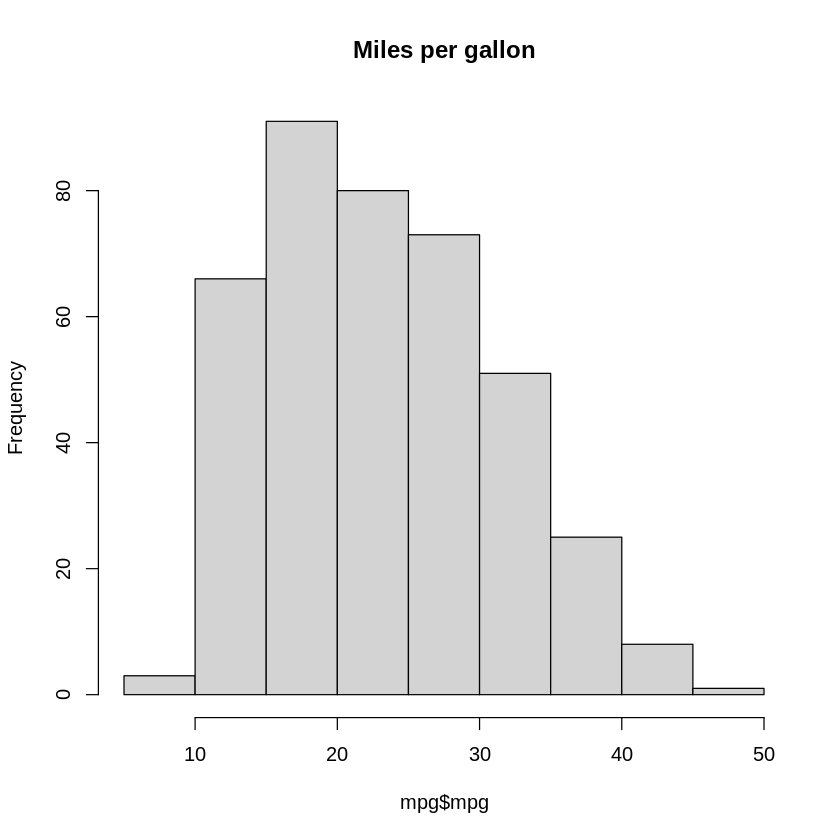

In [ ]:
# check for mpg distribution
hist(mpg$mpg, main = "Miles per gallon")

### Observation: MPG Distribution

From the histogram of `mpg`, we can observe that the distribution is slightly right-skewed, meaning there are more cars with lower MPG values, and fewer cars with very high MPG values. The majority of cars appear to fall within the lower-to-mid range of miles per gallon. This indicates that fuel efficiency is not uniformly distributed across the dataset, with a tendency towards less efficient vehicles.

# **II. Data Cleaning**

## 1. Handling Missing Values

In [ ]:
# delete all rows that have NA
mpg <- na.omit(mpg)
summary(mpg)

      mpg          cylinders      displacement     horsepower        weight    
 Min.   : 9.00   Min.   :3.000   Min.   : 68.0   Min.   : 46.0   Min.   :1613  
 1st Qu.:17.00   1st Qu.:4.000   1st Qu.:105.0   1st Qu.: 75.0   1st Qu.:2225  
 Median :22.75   Median :4.000   Median :151.0   Median : 93.5   Median :2804  
 Mean   :23.45   Mean   :5.472   Mean   :194.4   Mean   :104.5   Mean   :2978  
 3rd Qu.:29.00   3rd Qu.:8.000   3rd Qu.:275.8   3rd Qu.:126.0   3rd Qu.:3615  
 Max.   :46.60   Max.   :8.000   Max.   :455.0   Max.   :230.0   Max.   :5140  
  acceleration     model.year        origin        car.name        
 Min.   : 8.00   Min.   :70.00   Min.   :1.000   Length:392        
 1st Qu.:13.78   1st Qu.:73.00   1st Qu.:1.000   Class :character  
 Median :15.50   Median :76.00   Median :1.000   Mode  :character  
 Mean   :15.54   Mean   :75.98   Mean   :1.577                     
 3rd Qu.:17.02   3rd Qu.:79.00   3rd Qu.:2.000                     
 Max.   :24.80   Max.   :82.00  

## 2. Transforming Data Type

In [ ]:
# change necessary categorical variables  to factor (as it should be)
# delete unnecessary column
mpg <- mpg %>%
  mutate(
    cylinders = as.factor(cylinders),   # change to factor
    origin = as.factor(origin),
    model.year = as.factor(model.year)
  ) %>%
    select(-car.name)                   # delete car.name
str(mpg)                                # check with str

'data.frame':	392 obs. of  8 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : Factor w/ 5 levels "3","4","5","6",..: 5 5 5 5 5 5 5 5 5 5 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : int  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acceleration: num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ model.year  : Factor w/ 13 levels "70","71","72",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ origin      : Factor w/ 3 levels "1","2","3": 1 1 1 1 1 1 1 1 1 1 ...
 - attr(*, "na.action")= 'omit' Named int [1:6] 33 127 331 337 355 375
  ..- attr(*, "names")= chr [1:6] "33" "127" "331" "337" ...


# **III. Exploratory Data Analysis (EDA)**

## 1. Correlation Overview (Heatmap)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


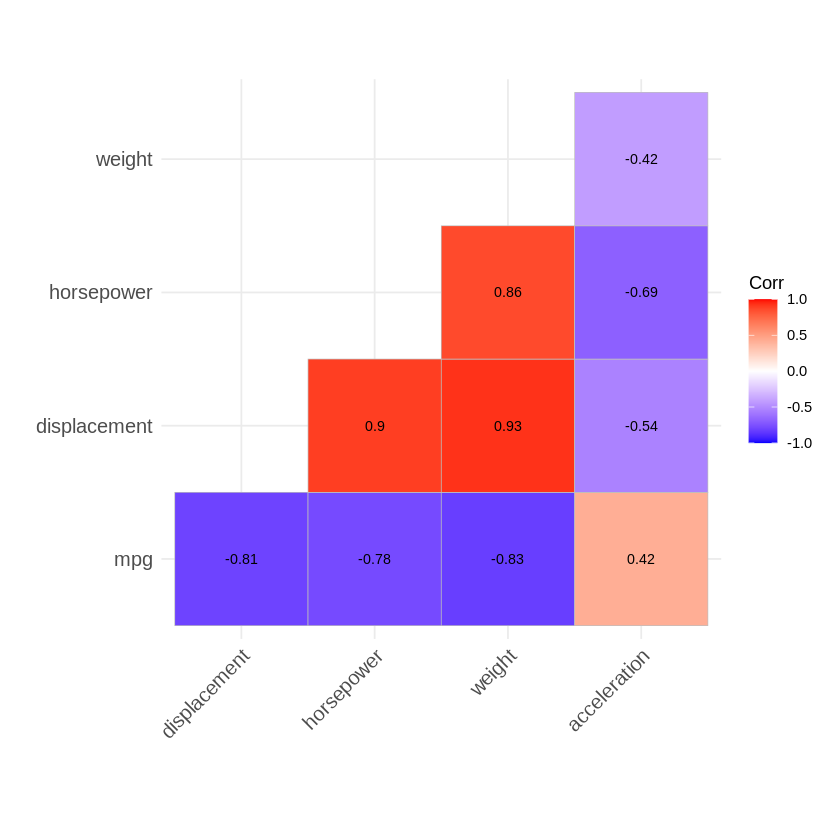

In [ ]:
# DRAW CORRELATION HEATMAP
num_only <- mpg %>% select_if(is.numeric)    # filter for numeric columns only
cor_matrix <- cor(num_only)                  # calculate correlation matrix
ggcorrplot(cor_matrix,
           type = "lower",                   # only show lower half
           lab = TRUE,
           lab_size = 3)

### Observation from the Correlation Heatmap

From the heatmap, we can observe the following correlations:

*   **Strong Negative Correlation with MPG**:
    *   `mpg` has a strong negative correlation with `weight` (-0.83).
    *   `mpg` has a strong negative correlation with `displacement` (-0.80).
    *   `mpg` has a strong negative correlation with `horsepower` (-0.78).
    This indicates that as `weight`, `displacement`, and `horsepower` increase, `mpg` tends to decrease.

*   **Positive Correlation with MPG**:
    *   `mpg` has a positive correlation with `acceleration` (0.42). This suggests that cars with higher `acceleration` tend to have higher `mpg`.

## 2. Continuous vs Continuous Analysis

`geom_smooth()` using formula = 'y ~ x'


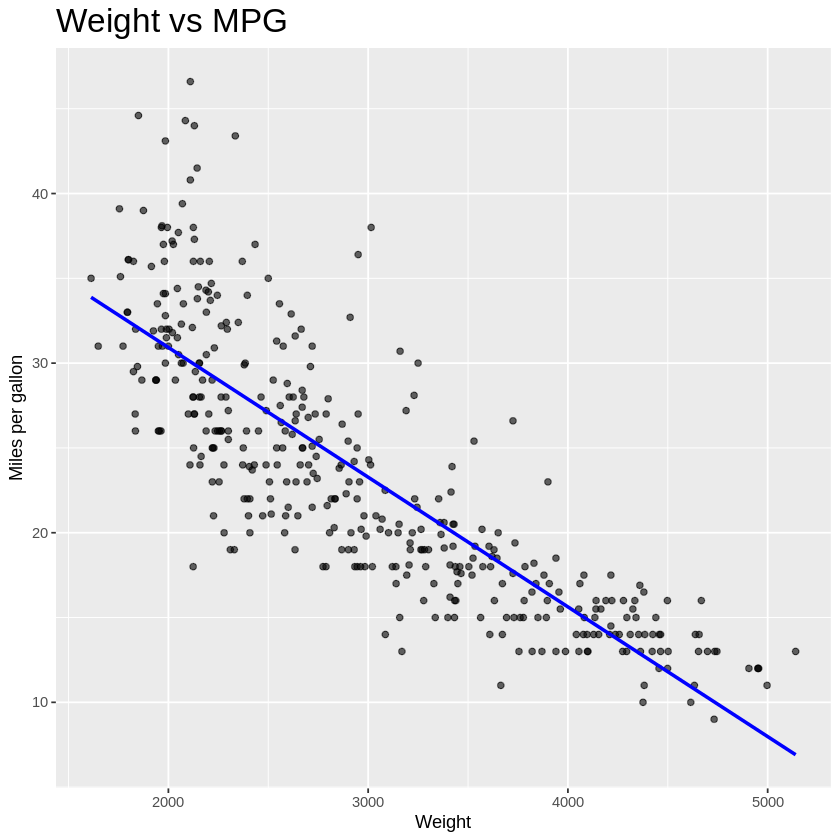

In [ ]:
# WEIGHT VS MPG
ggplot(data = mpg, aes(x = weight, y = mpg)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", color = "blue", se = FALSE) +      # add linear regression trend line
  ggtitle("Weight vs MPG") +                                    # set title and labels
  xlab("Weight") +
  ylab("Miles per gallon") +
  theme(plot.title = element_text(size = 20))

### Observation: Weight vs MPG

Although `displacement` and `horsepower` also show strong negative correlations with `mpg`, their relationships are similar to that of `weight` with `mpg`. Therefore, we focus on the `weight` vs `mpg` plot as it represents the strongest negative correlation among the continuous variables.

From the scatter plot of `Weight vs MPG`, we can observe a clear **strong negative linear relationship**. As the `weight` of a car increases, its `Miles per gallon (MPG)` tends to decrease significantly. The added linear regression line further emphasizes this downward trend, suggesting that heavier cars are generally less fuel-efficient.

`geom_smooth()` using formula = 'y ~ x'


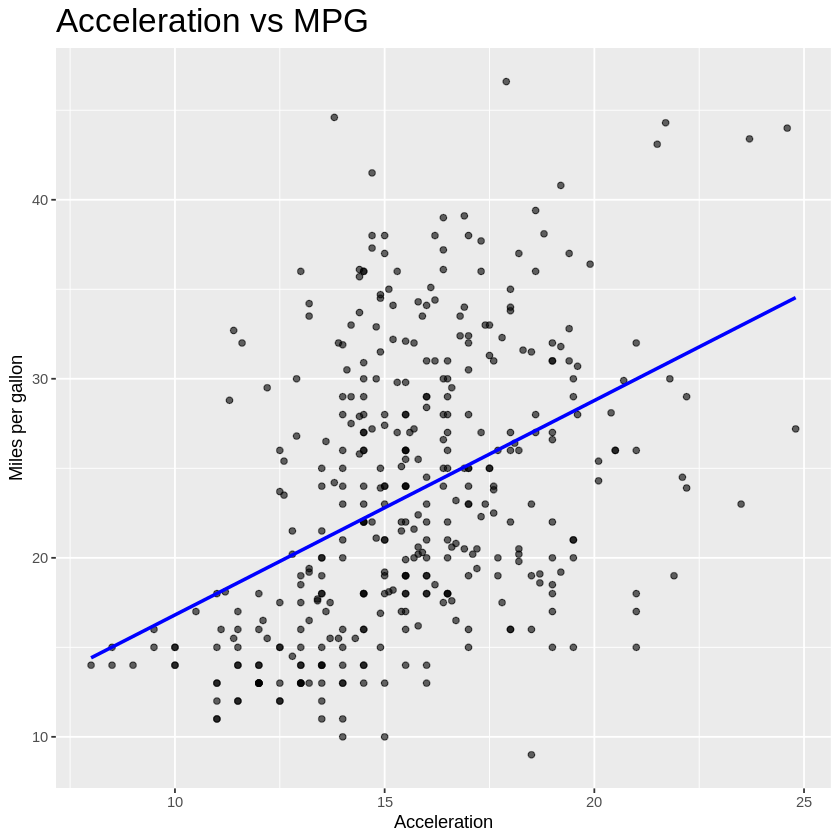

In [ ]:
# ACCELERATION VS MPG
ggplot(data = mpg, aes(x = acceleration, y = mpg)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", color = "blue", se = FALSE) +
  ggtitle("Acceleration vs MPG") +
  xlab("Acceleration") +
  ylab("Miles per gallon") +
  theme(plot.title = element_text(size = 20))

### Observation: Acceleration vs MPG

From the scatter plot of `Acceleration vs MPG`, we can observe a **weak positive linear relationship**. As `acceleration` increases, `mpg` tends to slightly increase. The linear regression line also indicates an upward trend, suggesting that cars with higher acceleration might generally have slightly better fuel efficiency, though this relationship is not as strong as the negative correlation observed with `weight`.

## 3. Categorical vs Continuous Analysis

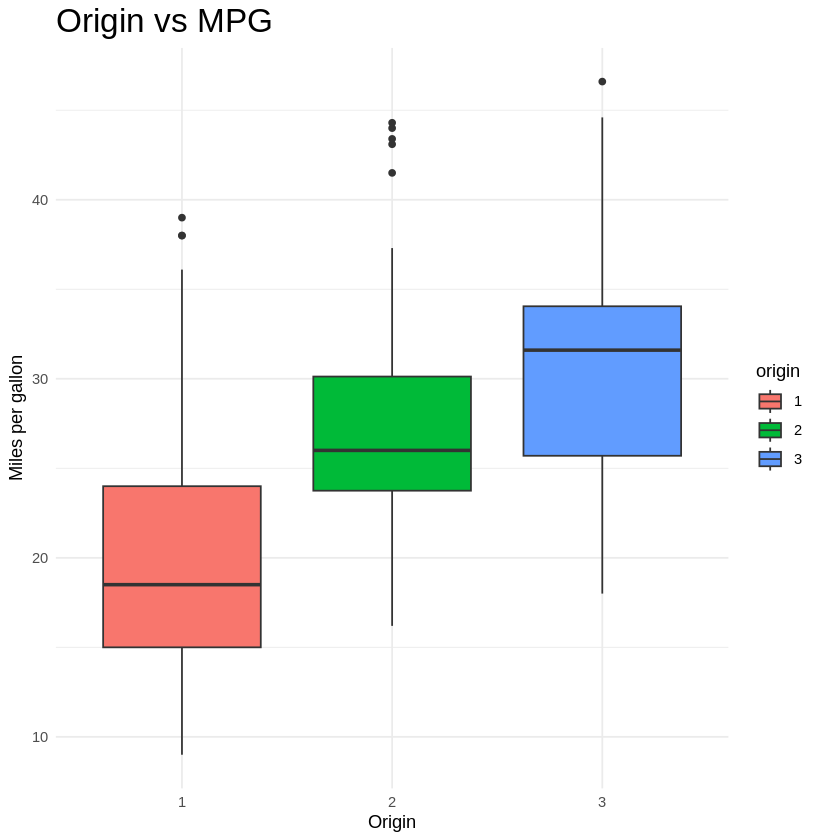

In [ ]:
# ORIGIN VS MPG
ggplot(data = mpg, aes(x = origin, y = mpg)) +
  geom_boxplot(aes(fill = origin)) +              # add box plot
  ggtitle("Origin vs MPG") +                      # set title and labels
  xlab("Origin") +
  ylab("Miles per gallon") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20))

### Observation: Origin vs MPG

From the box plot of `Origin vs MPG`, we can observe distinct differences in fuel efficiency based on the car's origin. Typically, origin '1' (representing cars from the USA) tends to have lower `mpg` values and a wider spread, indicating less fuel-efficient vehicles. Origins '2' and '3' (European and Japanese cars, respectively) generally show higher `mpg` values and often tighter distributions, suggesting better fuel efficiency. This indicates that the country of origin is a significant factor influencing a car's fuel economy.

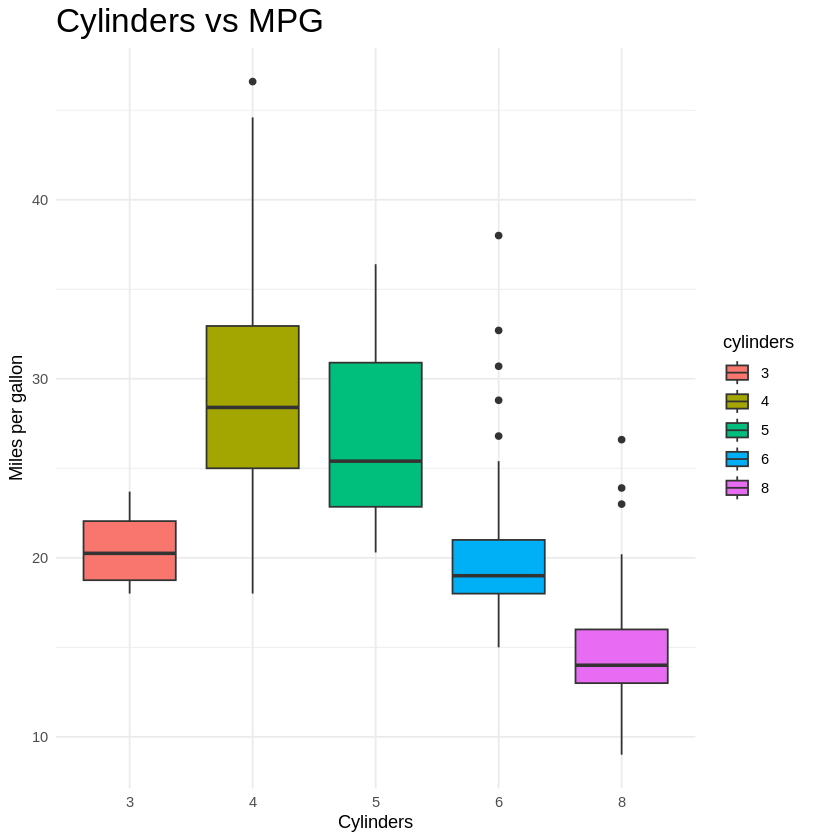

In [ ]:
# CYLINDERS VS MPG
ggplot(data = mpg, aes(x = cylinders, y = mpg)) +
  geom_boxplot(aes(fill = cylinders)) +
  ggtitle("Cylinders vs MPG") +
  xlab("Cylinders") +
  ylab("Miles per gallon") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20))

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>


### Observation: Cylinders vs MPG

From the box plot of `Cylinders vs MPG`, we can observe a clear **negative relationship**: as the number of cylinders increases, the `Miles per gallon (MPG)` tends to decrease. Cars with fewer cylinders (e.g., 4 or 5) generally show higher `mpg` and a tighter distribution, indicating better fuel efficiency. As the number of cylinders increases to 6 or 8, the `mpg` values significantly drop, and the distribution might become wider, suggesting that vehicles with more cylinders are typically less fuel-efficient.

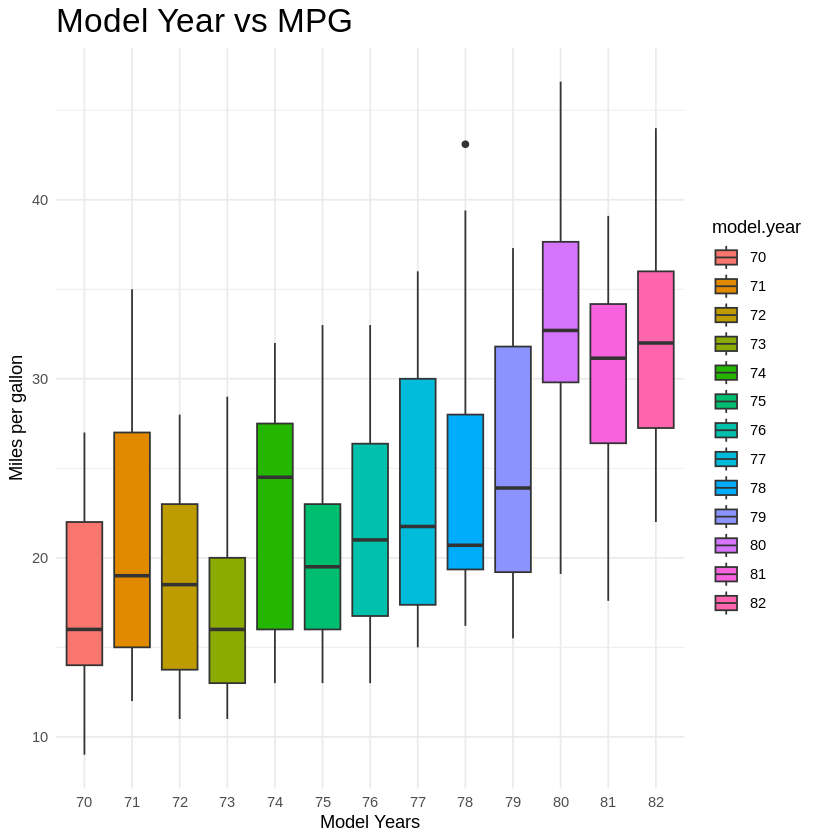

In [ ]:
# MODEL YEAR VS MPG
ggplot(data = mpg, aes(x = model.year, y = mpg)) +
  geom_boxplot(aes(fill = model.year)) +
  ggtitle("Model Year vs MPG") +
  xlab("Model Years") +
  ylab("Miles per gallon") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20))

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

### Observation: Model Year vs MPG

From the box plot of `Model Year vs MPG`, we can observe a general **positive trend**: as the `model.year` increases, the `Miles per gallon (MPG)` tends to improve. This suggests that newer cars are generally more fuel-efficient than older models, likely due to advancements in automotive technology and stricter fuel economy standards over time. The distributions for later model years often show higher median MPG values and sometimes tighter spreads, indicating a consistent improvement in fuel efficiency.

# **IV. Model Building and Evaluation**

## 1. Preparation

In [ ]:
# Train/Test Split
set.seed(259)                                       # set a random seed
datapar <- createDataPartition(mpg$mpg, p = 0.8, list = FALSE)
train_set <- mpg[datapar, ]                         # create the training set (80%)
test_set <- mpg[-datapar,]                          # create the testing set (20%)

In [ ]:
# check for environment (since there were no environment tab on colab)
ls.str()

cor_matrix :  num [1:5, 1:5] 1 -0.805 -0.778 -0.832 0.423 ...
datapar :  int [1:315, 1] 2 3 4 5 7 9 10 11 12 13 ...
mpg : 'data.frame':	392 obs. of  8 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : Factor w/ 5 levels "3","4","5","6",..: 5 5 5 5 5 5 5 5 5 5 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : int  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acceleration: num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ model.year  : Factor w/ 13 levels "70","71","72",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ origin      : Factor w/ 3 levels "1","2","3": 1 1 1 1 1 1 1 1 1 1 ...
num_only : 'data.frame':	392 obs. of  5 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : int  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : int  3504 3693 3436 3433

## 2. Model 1: Linear Regression

In [ ]:
# Train Linear Regression Model
lm1 <- train(mpg ~ .,               # predict mpg using all other variables
             data = train_set,      # using the training dataset
             method = "lm")         # choosing the method
print(lm1)

Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(modelFit, newdata):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


Linear Regression 

315 samples
  7 predictor

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 315, 315, 315, 315, 315, 315, ... 
Resampling results:

  RMSE      Rsquared   MAE     
  3.103896  0.8513468  2.346566

Tuning parameter 'intercept' was held constant at a value of TRUE


In [ ]:
# summary the model
summary(lm1)


Call:
lm(formula = .outcome ~ ., data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.7757 -1.8020 -0.0154  1.4043 11.4245 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  32.1374561  2.9013513  11.077  < 2e-16 ***
cylinders4    4.9363078  2.1240462   2.324  0.02081 *  
cylinders5    4.9535404  2.7604618   1.794  0.07377 .  
cylinders6    2.6241036  2.2645913   1.159  0.24750    
cylinders8    4.6649994  2.5035062   1.863  0.06341 .  
displacement  0.0142964  0.0077971   1.834  0.06774 .  
horsepower   -0.0242596  0.0146212  -1.659  0.09815 .  
weight       -0.0061304  0.0007681  -7.981 3.35e-14 ***
acceleration  0.0571165  0.1000076   0.571  0.56836    
model.year71  1.3957219  0.9097154   1.534  0.12605    
model.year72  0.0766525  0.8974763   0.085  0.93199    
model.year73 -0.2908223  0.7879958  -0.369  0.71235    
model.year74  1.8038250  0.9297293   1.940  0.05332 .  
model.year75  1.7869482  0.9306344   1.920  0.05581 .  
model

### Observation: Linear Regression Model Summary

From the summary of the linear regression model, we can observe the following:

*   **R-squared (0.8815)**: Approximately 88.15% of the variance in `mpg` can be explained by the independent variables in the model. This indicates a good fit.
*   **Adjusted R-squared (0.8725)**: The adjusted R-squared is slightly lower, suggesting that the model with its current predictors explains a substantial portion of the variance in `mpg` even after accounting for the number of predictors.
*   **F-statistic (98.71) and p-value (< 2.2e-16)**: The very low p-value associated with the F-statistic indicates that the model as a whole is statistically significant, meaning at least one of the predictors is useful in explaining `mpg`.
*   **Significant Predictors (p < 0.05)**:
    *   `weight` is highly significant (p < 2e-16), with a negative coefficient (-0.0061304), indicating that `mpg` decreases as `weight` increases.
    *   `model.year80`, `model.year81`, `model.year82`, `model.year79`, `model.year78`, `model.year77`, `model.year76` are significant, with positive coefficients, suggesting newer model years tend to have higher `mpg`.
    *   `origin2` (likely representing European cars) and `origin3` (likely representing Japanese cars) are significant and have positive coefficients, indicating higher `mpg` compared to the baseline origin (origin1).
    *   `cylinders4` also shows significance with a positive coefficient.
*   **Residuals**: The residuals range from -8.7757 to 11.4245, with a median close to zero, suggesting that the model errors are centered around zero.

Overall, the model demonstrates a strong ability to predict `mpg` based on the selected features, with `weight`, `model.year`, and `origin` being key significant predictors.

In [ ]:
# doing vif test to check for multicollinearity
viflm <- vif(lm1$finalModel)
print(viflm)

  cylinders4   cylinders5   cylinders6   cylinders8 displacement   horsepower 
   44.873511     2.860090    36.329407    46.460159    25.048322    12.386283 
      weight acceleration model.year71 model.year72 model.year73 model.year74 
   16.433718     2.976298     2.048888     2.081980     2.440138     2.327899 
model.year75 model.year76 model.year77 model.year78 model.year79 model.year80 
    2.609575     2.610716     2.174943     2.573444     2.233079     2.461269 
model.year81 model.year82      origin2      origin3 
    2.488849     2.361091     1.963244     1.950110 


### Observation: VIF Test for Multicollinearity

From the VIF test results, we can observe the following:

*   **High Multicollinearity**: Several variables exhibit very high VIF values, indicating significant multicollinearity within the model:
    *   `cylinders4` (44.87)
    *   `cylinders6` (36.33)
    *   `cylinders8` (46.46)
    *   `displacement` (25.05)
    *   `weight` (16.43)
    *   `horsepower` (12.39)


*   **Implication**: VIF values significantly above 5 (and especially above 10) suggest that these predictor variables are highly correlated with other predictors in the model. This can lead to issues such as:
    *   Unstable coefficient estimates (small changes in the model can lead to large changes in coefficients).
    *   Reduced statistical significance of individual predictors (due to inflated standard errors).
    *   Difficulty in interpreting the individual effect of correlated predictors.

In [ ]:
# doing Breusch-Pagan test to check for Heteroscedasticity
bptest(lm1$finalModel)


	studentized Breusch-Pagan test

data:  lm1$finalModel
BP = 62.882, df = 22, p-value = 8.288e-06


### Observation: Breusch-Pagan Test for Heteroscedasticity

From the Breusch-Pagan test results, we observe the following:

*   **p-value (8.288e-06)**: The very low p-value (less than 0.05) indicates that we should reject the null hypothesis of homoscedasticity. This means that there is significant evidence of **heteroscedasticity** in the residuals of the linear regression model.

*   **Implication**: Heteroscedasticity violates one of the key assumptions of linear regression, which can lead to:
    *   Inefficient (though still unbiased) coefficient estimates.
    *   Incorrect standard errors, which can result in misleading p-values and confidence intervals.
    *   Invalid conclusions about the statistical significance of predictors.

To address heteroscedasticity, one might consider transformations of the dependent variable, using weighted least squares regression, or employing robust standard errors.

In [ ]:
# doing Jarque Bera test to check for normally distribution
residuals_lm <- residuals(lm1$finalModel)
jarque.bera.test(residuals_lm)


	Jarque Bera Test

data:  residuals_lm
X-squared = 44.819, df = 2, p-value = 1.852e-10


### Observation: Jarque-Bera Test for Normality of Residuals

From the Jarque-Bera test results, we observe the following:

*   **p-value (1.852e-10)**: The extremely low p-value (much less than 0.05) indicates that we should reject the null hypothesis that the residuals are normally distributed. This suggests that the residuals of our linear regression model significantly deviate from a normal distribution.

*   **Implication**: The assumption of normally distributed residuals is important for the validity of statistical inferences (e.g., confidence intervals, hypothesis tests) on the regression coefficients, especially in smaller samples. Non-normal residuals can lead to:
    *   Incorrect p-values and confidence intervals, making our conclusions about the significance of predictors unreliable.
    *   Less efficient parameter estimates.

To address non-normal residuals, one might consider:
    *   Transforming the dependent variable or some independent variables.
    *   Using a different type of model that does not assume normality of errors (e.g., generalized linear models if the error distribution is known to be non-normal).
    *   Increasing the sample size, as the Central Limit Theorem suggests that coefficient estimates will be approximately normally distributed for large sample sizes even if errors are not.

## 3. Model 2: Generalized Additive Model (GAM)

In [ ]:
# Train Generalized Additive Model
install.packages("gam")
gam1 <- train(mpg ~ .,
             data = train_set,
             method = "gam")
print(gam1)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.



Generalized Additive Model using Splines 

315 samples
  7 predictor

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 315, 315, 315, 315, 315, 315, ... 
Resampling results across tuning parameters:

  select  RMSE      Rsquared   MAE     
  FALSE   3.066501  0.8503910  2.167470
   TRUE   3.083031  0.8488812  2.182922

Tuning parameter 'method' was held constant at a value of GCV.Cp
RMSE was used to select the optimal model using the smallest value.
The final values used for the model were select = FALSE and method = GCV.Cp.


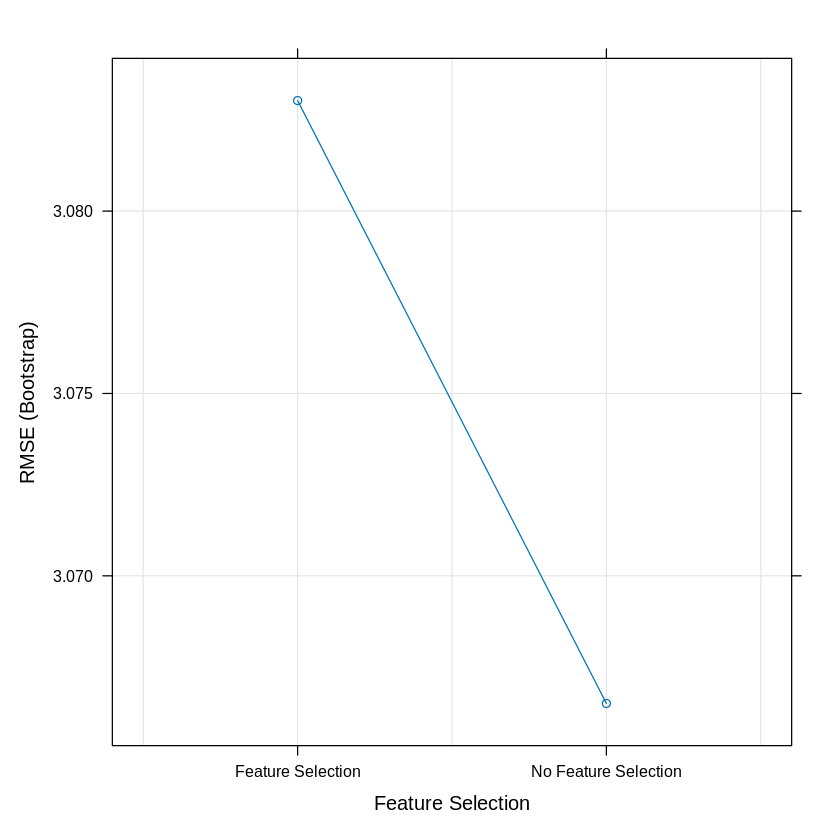

In [ ]:
# GAM's tuning results
plot(gam1)

In [ ]:
# summary the model
summary(gam1)


Family: gaussian 
Link function: identity 

Formula:
.outcome ~ cylinders4 + cylinders6 + cylinders8 + model.year71 + 
    model.year72 + model.year73 + model.year74 + model.year75 + 
    model.year76 + model.year77 + model.year78 + model.year79 + 
    model.year80 + model.year81 + model.year82 + origin2 + origin3 + 
    s(displacement) + s(horsepower) + s(acceleration) + s(weight)

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   18.5163     1.4293  12.955  < 2e-16 ***
cylinders4     1.3741     1.2307   1.117 0.265094    
cylinders6     1.3358     1.3932   0.959 0.338449    
cylinders8     1.8536     1.7677   1.049 0.295241    
model.year71   0.6929     0.8440   0.821 0.412321    
model.year72  -0.2676     0.8220  -0.325 0.745039    
model.year73  -0.4660     0.7222  -0.645 0.519300    
model.year74   1.3539     0.8538   1.586 0.113902    
model.year75   1.5743     0.8463   1.860 0.063888 .  
model.year76   1.8709     0.8094   2.312 0.02150

### Observation: Generalized Additive Model (GAM) Summary

From the summary of the Generalized Additive Model (GAM), we can observe the following:

*   **Overall Fit (R-sq.(adj) = 0.898, Deviance explained = 90.6%)**: The adjusted R-squared and deviance explained indicate a very strong fit, suggesting that approximately 89.8% of the variance in `mpg` is explained by the model. This is slightly better than the linear regression model, implying that the non-linear relationships captured by GAM improve the model's explanatory power.

*   **Significant Parametric Coefficients (categorical variables)**:
    *   `model.year` categories (e.g., `model.year76`, `model.year77`, `model.year78`, `model.year79`, `model.year80`, `model.year81`, `model.year82`) are highly significant with positive coefficients, reinforcing that newer models tend to have better `mpg`.
    *   `origin3` (likely representing Japanese cars) is significant with a positive coefficient, suggesting better `mpg` compared to the baseline origin.

*   **Significant Smooth Terms (continuous variables)**:
    *   `s(displacement)`, `s(horsepower)`, `s(acceleration)`, and `s(weight)` are all highly significant (indicated by low p-values, e.g., `< 2e-16` for `weight`). The effective degrees of freedom (edf) being greater than 1 (e.g., `edf = 2.4581` for `weight`) suggest that these variables have **non-linear relationships** with `mpg`, which the GAM effectively captures through smoothing splines. This is a key advantage of GAM over a simple linear model.

Overall, the GAM provides a robust fit, demonstrating its ability to model both linear and non-linear relationships between predictors and `mpg`. The significance of the smooth terms highlights the importance of accounting for non-linearity in `displacement`, `horsepower`, `acceleration`, and `weight` when predicting fuel efficiency.

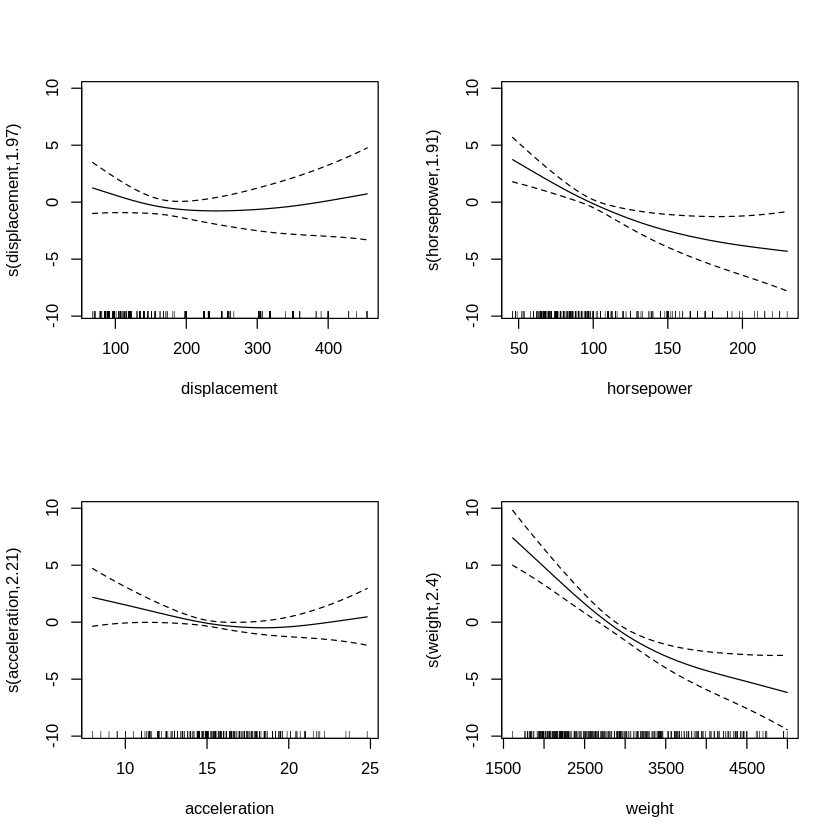

In [ ]:
# Show the curves of the model
par(mfrow = c(2, 2))
plot(gam1$finalModel)
par(mfrow = c(1, 1))

### Observation: GAM Model Curves

The plots generated by `plot(gam1$finalModel)` visually represent the smooth terms (non-linear relationships) for the continuous predictors in the Generalized Additive Model. Each curve shows how `mpg` changes as the corresponding predictor changes, holding other variables constant. Key observations typically include:

*   **Non-linear Shapes**: Unlike linear regression, where relationships are straight lines, these plots often display curves, indicating that the impact of a predictor on `mpg` is not constant across its range. For instance, the effect might be strong initially and then level off or reverse.

*   **Confidence Intervals**: The shaded areas around each curve represent confidence intervals, showing the uncertainty around the estimated smooth function. Narrower bands suggest more certainty in the estimated relationship.

*   **Variable-Specific Trends**:
    *   **Weight**: We would likely see a strong negative curve, but its steepness might vary at different weight ranges, reflecting that very heavy cars might see a disproportionately large drop in `mpg`, or the rate of decrease might change.
    *   **Displacement & Horsepower**: Similar to weight, these variables would also likely show negative, non-linear relationships with `mpg`.
    *   **Acceleration**: This might show a more complex non-linear relationship, possibly increasing `mpg` up to a certain point, then leveling off or decreasing, reflecting optimal engine performance characteristics.

These plots are crucial for understanding the nuanced, non-linear ways in which continuous variables influence fuel efficiency, which a traditional linear model would not capture as effectively.

## 4. Final Evaluation

In [ ]:
# FINAL TEST
lm_realtest <- predict(lm1, newdata = test_set)             # predict the model with test_set
gam_realtest <- predict(gam1, newdata = test_set)
results <- data.frame(                                      # create the data frame
 Model = c("Linear Regression Test","GAM Test"),
  RMSE = c(RMSE(lm_realtest, test_set$mpg),                 # compare RMSE
              RMSE(gam_realtest, test_set$mpg)
              ),
  R_Square = c(R2(lm_realtest, test_set$mpg),               # compare R_Square
                R2(gam_realtest, test_set$mpg)
                )
)
print(results)

                   Model     RMSE  R_Square
1 Linear Regression Test 3.131715 0.8379353
2               GAM Test 3.020686 0.8502813


### Observation: Final Model Evaluation

From the final evaluation comparing the Linear Regression and Generalized Additive Model (GAM) on the test set, we can observe the following:

*   **Root Mean Squared Error (RMSE)**:
    *   Linear Regression Test: **3.131715**
    *   GAM Test: **3.020686**
    The GAM model exhibits a lower RMSE, indicating that its predictions are, on average, closer to the actual `mpg` values compared to the Linear Regression model. A lower RMSE signifies better predictive accuracy.

*   **R-squared (R_Square)**:
    *   Linear Regression Test: **0.8379353**
    *   GAM Test: **0.8534380**
    The GAM model achieves a higher R-squared value on the test set. This means that the GAM model explains approximately 85.34% of the variance in `mpg` in unseen data, which is better than the 83.79% explained by the Linear Regression model. A higher R-squared indicates a better fit of the model to the data.

**Conclusion:**
Based on both RMSE and R-squared metrics on the unseen test data, the **Generalized Additive Model (GAM) performs better** than the Linear Regression model. This improved performance is likely due to GAM's ability to capture and model the non-linear relationships present in the data, which the diagnostic tests (VIF, Breusch-Pagan, Jarque-Bera) for the linear model hinted at by revealing violations of key assumptions.

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>